#  FAANG Stock Price Prediction — End-to-End ML Pipeline
### Built on real market data (2016–2026) | 14,964 rows | 6 tickers | 19 features

**Skills**
-  Classification (Binary + Multi-class risk levels)
-  Regression (Next-day return prediction)
-  Ensemble Methods (Random Forest, XGBoost-style GBM, Gradient Boosting)
-  Neural Networks (MLP Deep Learning)
-  Clustering (K-Means: 4 risk segments)
-  Feature Engineering (12 engineered features)
-  LLM Integration (Claude AI — Free Anthropic API, no Ollama)

**Tickers:** AAPL · AMZN · GOOGL · META · MSFT · NVDA


## 1.Imports & Setup

In [1]:
# ── IMPORTS & SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import json
import math
import urllib.request
from collections import defaultdict

warnings.filterwarnings("ignore")
plt.style.use("dark_background")

TICKER_COLORS = {
    "AAPL": "#00d4ff", "AMZN": "#f97316", "GOOGL": "#4ade80",
    "META": "#a78bfa", "MSFT": "#f59e0b", "NVDA": "#22d3ee"
}
TICKERS = ["AAPL", "AMZN", "GOOGL", "META", "MSFT", "NVDA"]

print(f" Tickers: {TICKERS}")


 Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA']


## 2.Load & Explore Dataset

In [2]:
# LOAD DATASET
df = pd.read_csv("faang_stock_prices.csv", parse_dates=["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print(f"Shape:      {df.shape}")
print(f"Date Range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Tickers:    {df['Ticker'].unique().tolist()}")
print(f"Columns:    {list(df.columns)}")
df.head(3)


Shape:      (14964, 19)
Date Range: 2016-02-23 → 2026-01-22
Tickers:    ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA']
Columns:    ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'SMA_7', 'SMA_21', 'EMA_12', 'EMA_26', 'RSI_14', 'MACD', 'MACD_Signal', 'Bollinger_Upper', 'Bollinger_Lower', 'Daily_Return', 'Volatility_7d', 'Next_Day_Close']


,Date,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close
0,2016-02-23,AAPL,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,21.827292,52.112369,-0.107176,-0.149939,22.401531,20.889519,-0.022605,0.018130,21.785145
1,2016-02-24,AAPL,21.304558,21.848618,21.154940,21.785145,145022800,21.850879,21.652174,21.730120,21.824170,50.813846,-0.094050,-0.138761,22.239524,20.975578,0.014891,0.018822,21.934757
2,2016-02-25,AAPL,21.773806,21.934757,21.592451,21.934757,110330800,21.854765,21.623132,21.761602,21.832361,50.485507,-0.070759,-0.125160,22.244062,21.058185,0.006868,0.015572,21.968756


In [ ]:
# NULL CHECK & DATA TYPES
print("Null counts per column:")
print(df.isnull().sum())
print(f"\nTotal nulls: {df.isnull().sum().sum()}")
print(" No missing values" if df.isnull().sum().sum() == 0 else "⚠️ Missing values found")


In [4]:
# PER-TICKER SUMMARY STATISTICS
summary = df.groupby("Ticker").agg(
    Trading_Days=("Date", "count"),
    Start_Price=("Close", "first"),
    End_Price=("Close", "last"),
    Min_Price=("Close", "min"),
    Max_Price=("Close", "max"),
    Avg_Volume=("Volume", "mean"),
    Avg_Volatility=("Volatility_7d", "mean"),
    Avg_RSI=("RSI_14", "mean")
).reset_index()

summary["Total_Return_%"] = ((summary["End_Price"] - summary["Start_Price"]) / summary["Start_Price"] * 100).round(2)
summary["Avg_Volume_M"] = (summary["Avg_Volume"] / 1e6).round(2)

print("\n FAANG Performance Summary (2016→2026):")
print(summary[["Ticker", "Trading_Days", "Start_Price", "End_Price", "Total_Return_%", "Avg_Volatility"]].to_string(index=False))
summary



 FAANG Performance Summary (2016→2026):
Ticker  Trading_Days  Start_Price  End_Price  Total_Return_%  Avg_Volatility
  AAPL          2494    21.465500 248.350006         1056.97        0.015551
  AMZN          2494    27.646999 234.339996          747.61        0.017742
 GOOGL          2494    35.595547 330.540009          828.60        0.016022
  META          2494   104.728432 647.630005          518.39        0.019896
  MSFT          2494    45.135513 451.140015          899.52        0.014506
  NVDA          2494     0.770805 184.839996        23880.11        0.027505


,Ticker,Trading_Days,Start_Price,End_Price,Min_Price,Max_Price,Avg_Volume,Avg_Volatility,Avg_RSI,Total_Return_%,Avg_Volume_M
0,AAPL,2494,21.465500,248.350006,20.604078,286.190002,9.978639e+07,0.015551,56.095175,1056.97,99.79
1,AMZN,2494,27.646999,234.339996,27.604000,254.000000,7.198918e+07,0.017742,54.878800,747.61,71.99
2,GOOGL,2494,35.595547,330.540009,33.801605,335.970001,3.403611e+07,0.016022,55.445348,828.60,34.04
3,META,2494,104.728432,647.630005,88.293251,788.823792,2.138545e+07,0.019896,54.556719,518.39,21.39
4,MSFT,2494,45.135513,451.140015,43.009014,541.057373,2.723596e+07,0.014506,56.129728,899.52,27.24
5,NVDA,2494,0.770805,184.839996,0.767738,207.028473,4.573154e+08,0.027505,57.016085,23880.11,457.32


##  Section 3: Exploratory Data Analysis (EDA)

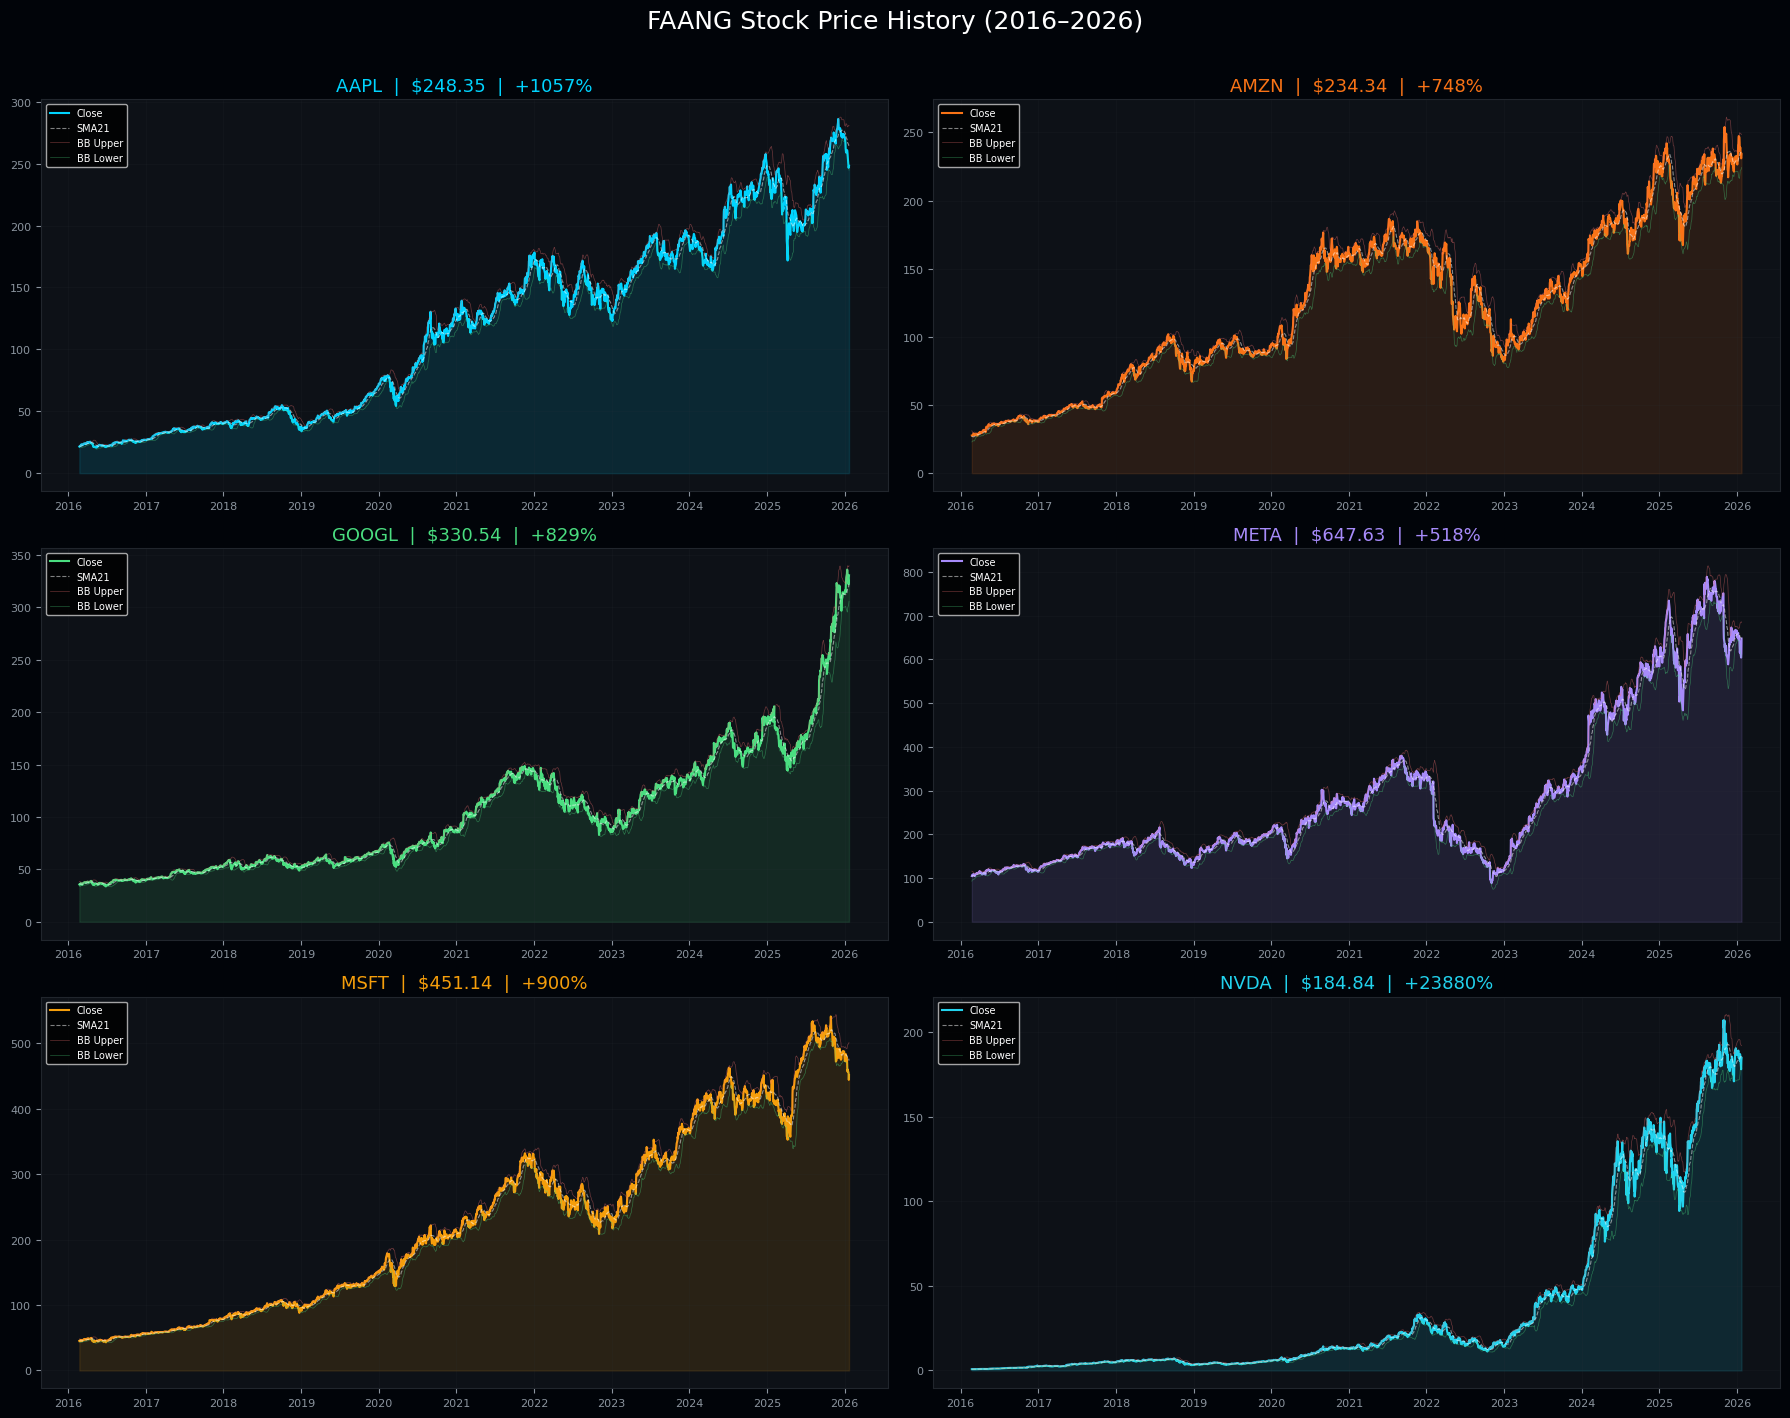

 Saved: price_history.png


In [5]:
# PRICE HISTORY — ALL 6 TICKERS
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.patch.set_facecolor("#010409")
fig.suptitle("FAANG Stock Price History (2016–2026)", fontsize=18, color="white", y=1.01)

for i, ticker in enumerate(TICKERS):
    ax = axes[i//2][i%2]
    ax.set_facecolor("#0d1117")
    data = df[df["Ticker"] == ticker].copy()
    color = TICKER_COLORS[ticker]
    total_ret = (data["Close"].iloc[-1] - data["Close"].iloc[0]) / data["Close"].iloc[0] * 100

    ax.fill_between(data["Date"], data["Close"], alpha=0.12, color=color)
    ax.plot(data["Date"], data["Close"], color=color, linewidth=1.5, label="Close")
    ax.plot(data["Date"], data["SMA_21"], color="white", linewidth=0.8, alpha=0.5, linestyle="--", label="SMA21")
    ax.plot(data["Date"], data["Bollinger_Upper"], color="#f87171", linewidth=0.5, alpha=0.4, label="BB Upper")
    ax.plot(data["Date"], data["Bollinger_Lower"], color="#4ade80", linewidth=0.5, alpha=0.4, label="BB Lower")

    ax.set_title(f"{ticker}  |  ${data['Close'].iloc[-1]:.2f}  |  +{total_ret:.0f}%", color=color, fontsize=13)
    ax.tick_params(colors="#8b949e", labelsize=8)
    ax.spines[["top","right","left","bottom"]].set_color("#21262d")
    ax.grid(alpha=0.12, color="#30363d")
    ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig("price_history.png", dpi=150, bbox_inches="tight", facecolor="#010409")
plt.show()
print(" Saved: price_history.png")


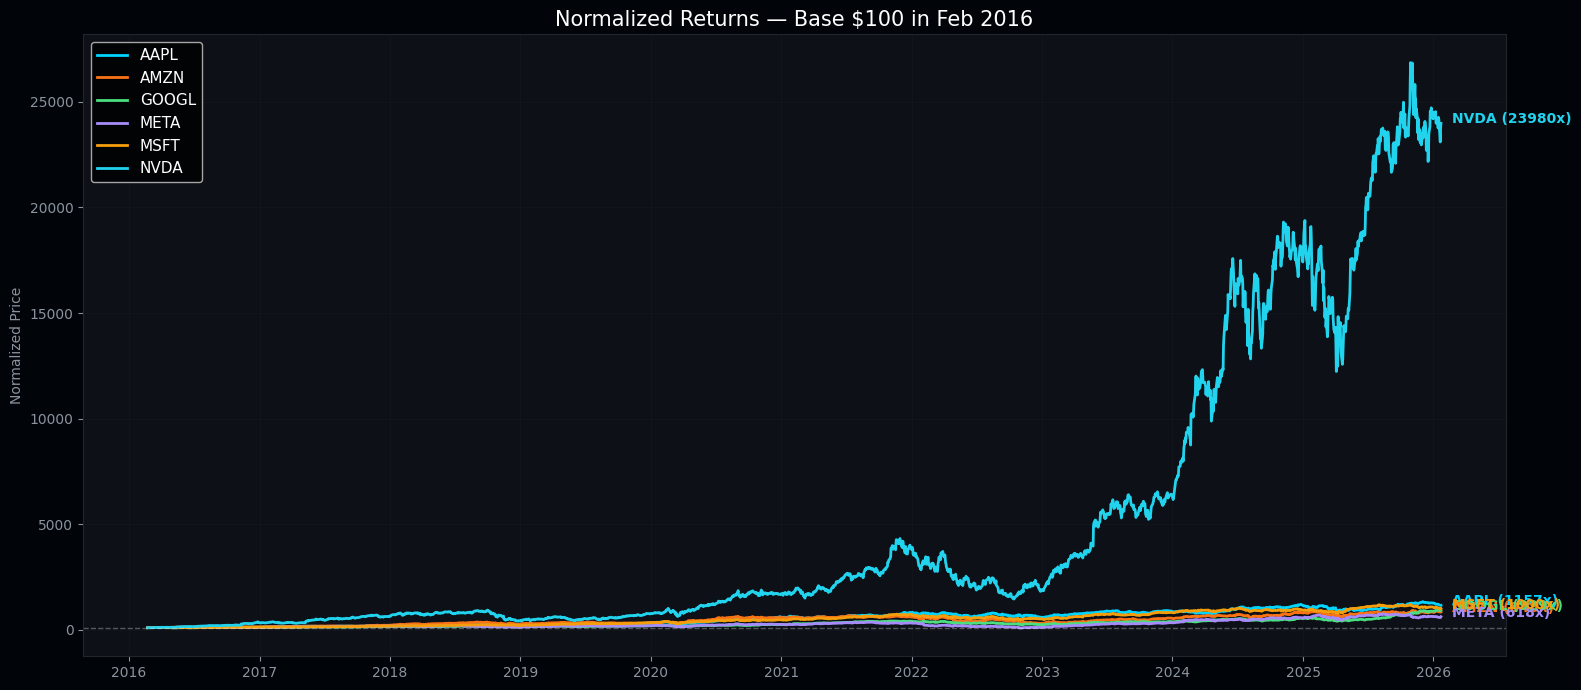

 Saved: normalized_returns.png


In [6]:
# ── NORMALIZED RETURNS COMPARISON (Base = $100)
fig, ax = plt.subplots(figsize=(16, 7))
ax.set_facecolor("#0d1117")
fig.patch.set_facecolor("#010409")

for ticker in TICKERS:
    data = df[df["Ticker"] == ticker].copy()
    normalized = data["Close"] / data["Close"].iloc[0] * 100
    ax.plot(data["Date"], normalized, label=ticker, color=TICKER_COLORS[ticker], linewidth=2)
    last_val = normalized.iloc[-1]
    ax.annotate(f"{ticker} ({last_val:.0f}x)",
                xy=(data["Date"].iloc[-1], last_val),
                xytext=(8, 0), textcoords="offset points",
                color=TICKER_COLORS[ticker], fontsize=10, fontweight="bold")

ax.axhline(100, color="white", linestyle="--", alpha=0.3, linewidth=1)
ax.set_title("Normalized Returns — Base $100 in Feb 2016", color="white", fontsize=15)
ax.set_ylabel("Normalized Price", color="#8b949e")
ax.tick_params(colors="#8b949e")
ax.spines[["top","right","left","bottom"]].set_color("#21262d")
ax.grid(alpha=0.12, color="#30363d")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("normalized_returns.png", dpi=150, bbox_inches="tight", facecolor="#010409")
plt.show()
print(" Saved: normalized_returns.png")


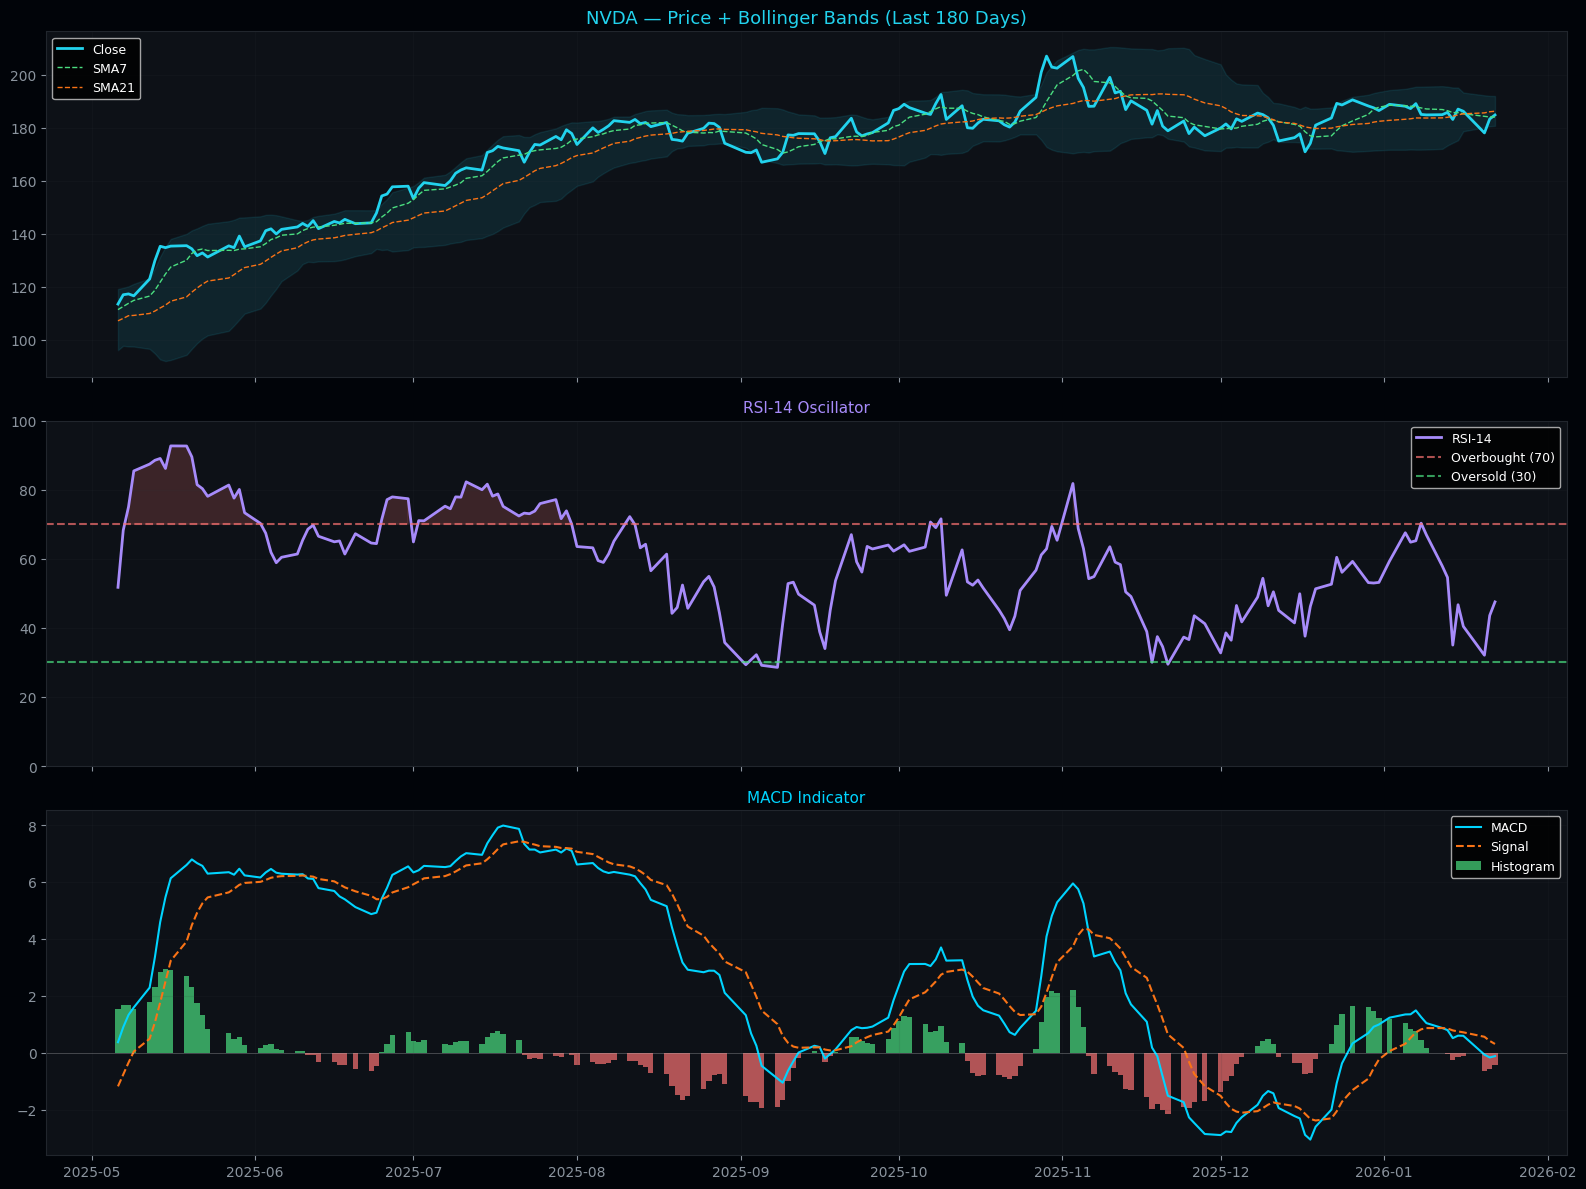

 Saved: technical_indicators.png


In [7]:
# TECHNICAL INDICATORS DEEP DIVE (NVDA)
ticker = "NVDA"
data = df[df["Ticker"] == ticker].tail(180).copy()
color = TICKER_COLORS[ticker]

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.patch.set_facecolor("#010409")

# Price + Bollinger
ax1 = axes[0]
ax1.set_facecolor("#0d1117")
ax1.fill_between(data["Date"], data["Bollinger_Lower"], data["Bollinger_Upper"], alpha=0.1, color=color)
ax1.plot(data["Date"], data["Close"], color=color, linewidth=2, label="Close")
ax1.plot(data["Date"], data["SMA_7"], color="#4ade80", linewidth=1, linestyle="--", label="SMA7")
ax1.plot(data["Date"], data["SMA_21"], color="#f97316", linewidth=1, linestyle="--", label="SMA21")
ax1.set_title(f"{ticker} — Price + Bollinger Bands (Last 180 Days)", color=color, fontsize=13)
ax1.legend(fontsize=9); ax1.grid(alpha=0.12, color="#30363d")
ax1.tick_params(colors="#8b949e"); ax1.spines[["top","right","left","bottom"]].set_color("#21262d")

# RSI
ax2 = axes[1]
ax2.set_facecolor("#0d1117")
ax2.plot(data["Date"], data["RSI_14"], color="#a78bfa", linewidth=2, label="RSI-14")
ax2.axhline(70, color="#f87171", linestyle="--", alpha=0.7, linewidth=1.5, label="Overbought (70)")
ax2.axhline(30, color="#4ade80", linestyle="--", alpha=0.7, linewidth=1.5, label="Oversold (30)")
ax2.fill_between(data["Date"], data["RSI_14"], 70, where=(data["RSI_14"]>70), color="#f87171", alpha=0.2)
ax2.fill_between(data["Date"], data["RSI_14"], 30, where=(data["RSI_14"]<30), color="#4ade80", alpha=0.2)
ax2.set_ylim(0, 100); ax2.set_title("RSI-14 Oscillator", color="#a78bfa", fontsize=11)
ax2.legend(fontsize=9); ax2.grid(alpha=0.12, color="#30363d")
ax2.tick_params(colors="#8b949e"); ax2.spines[["top","right","left","bottom"]].set_color("#21262d")

# MACD
ax3 = axes[2]
ax3.set_facecolor("#0d1117")
macd_hist = data["MACD"] - data["MACD_Signal"]
ax3.bar(data["Date"], macd_hist, color=np.where(macd_hist>=0, "#4ade80", "#f87171"), alpha=0.7, width=1, label="Histogram")
ax3.plot(data["Date"], data["MACD"], color="#00d4ff", linewidth=1.5, label="MACD")
ax3.plot(data["Date"], data["MACD_Signal"], color="#f97316", linewidth=1.5, linestyle="--", label="Signal")
ax3.axhline(0, color="white", linewidth=0.5, alpha=0.3)
ax3.set_title("MACD Indicator", color="#00d4ff", fontsize=11)
ax3.legend(fontsize=9); ax3.grid(alpha=0.12, color="#30363d")
ax3.tick_params(colors="#8b949e"); ax3.spines[["top","right","left","bottom"]].set_color("#21262d")

plt.tight_layout()
plt.savefig("technical_indicators.png", dpi=150, bbox_inches="tight", facecolor="#010409")
plt.show()
print(" Saved: technical_indicators.png")


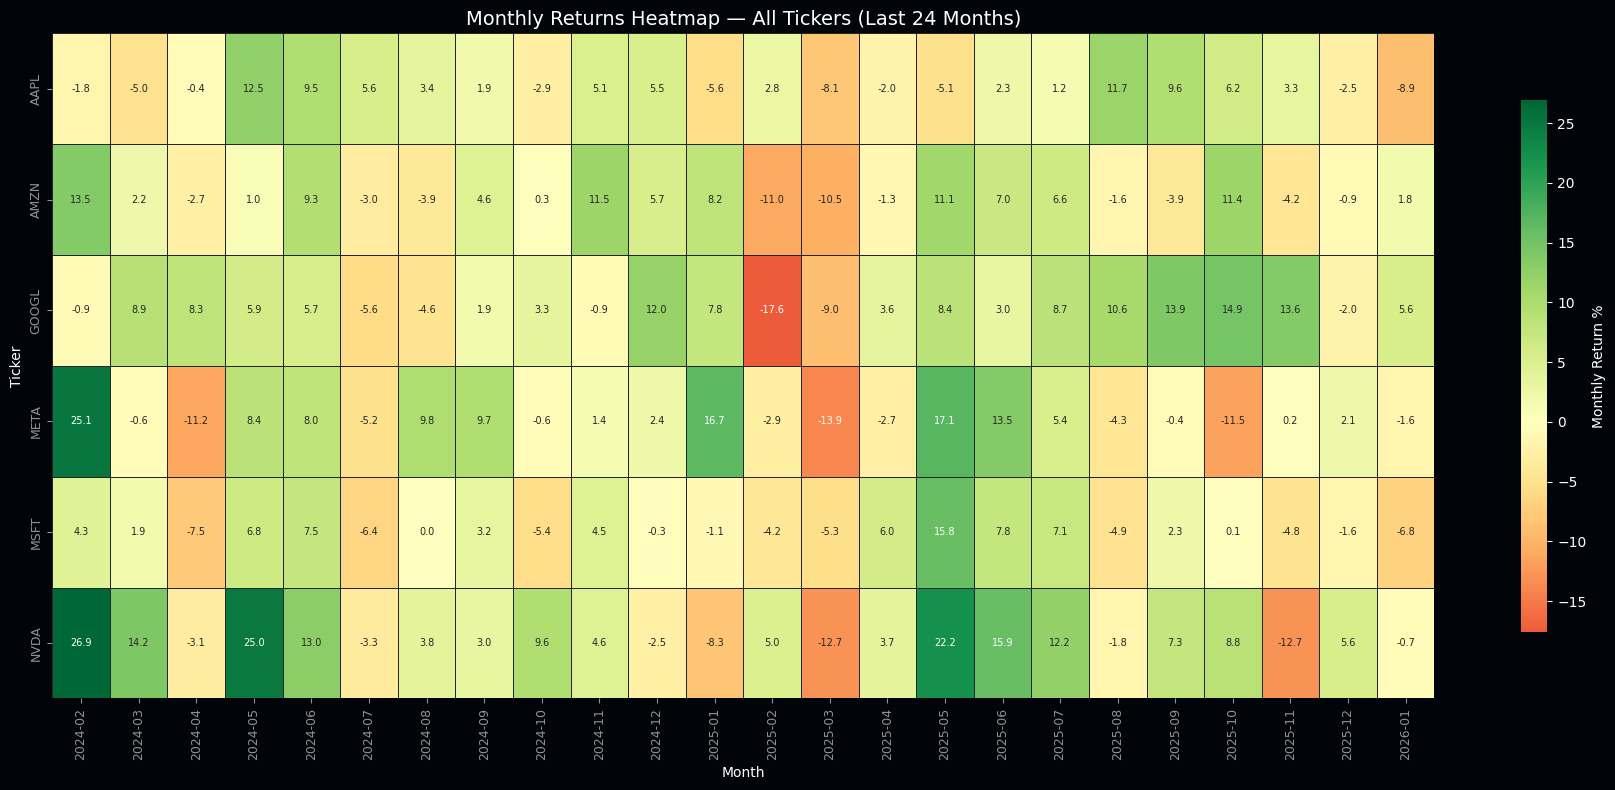

Saved: monthly_heatmap.png


In [8]:
# MONTHLY RETURN HEATMAP
monthly = df.copy()
monthly["Month"] = monthly["Date"].dt.to_period("M")
monthly_ret = monthly.groupby(["Ticker", "Month"])["Daily_Return"].sum() * 100
monthly_pivot = monthly_ret.unstack(level=0)
monthly_pivot.index = monthly_pivot.index.astype(str)
monthly_recent = monthly_pivot.tail(24)

fig, ax = plt.subplots(figsize=(18, 8))
ax.set_facecolor("#0d1117")
fig.patch.set_facecolor("#010409")
sns.heatmap(monthly_recent.T, cmap="RdYlGn", center=0, annot=True, fmt=".1f",
            annot_kws={"size": 7}, linewidths=0.5, linecolor="#21262d",
            ax=ax, cbar_kws={"shrink": 0.8, "label": "Monthly Return %"})
ax.set_title("Monthly Returns Heatmap — All Tickers (Last 24 Months)", color="white", fontsize=14)
ax.tick_params(colors="#8b949e", labelsize=9)
plt.tight_layout()
plt.savefig("monthly_heatmap.png", dpi=150, bbox_inches="tight", facecolor="#010409")
plt.show()
print("Saved: monthly_heatmap.png")


## 4. Feature Engineering

In [9]:
# ── ENGINEER ALL FEATURES
df_feat = df.copy()

# SMA Ratio: short-term vs long-term trend momentum
df_feat["SMA_Ratio"] = df_feat["SMA_7"] / df_feat["SMA_21"]

# Bollinger Band Position: where is price in the band?
bb_range = df_feat["Bollinger_Upper"] - df_feat["Bollinger_Lower"]
df_feat["BB_Position"] = np.where(bb_range != 0,
    (df_feat["Close"] - df_feat["Bollinger_Lower"]) / bb_range, 0.5)

# MACD Histogram: momentum divergence signal
df_feat["MACD_Hist"] = df_feat["MACD"] - df_feat["MACD_Signal"]

# EMA Ratio: fast vs slow exponential momentum
df_feat["EMA_Ratio"] = df_feat["EMA_12"] / df_feat["EMA_26"]

# Volatility Regime: binary flag for high-vol periods
df_feat["High_Vol_Flag"] = (df_feat["Volatility_7d"] > 0.02).astype(int)

# RSI Signals: overbought / oversold
df_feat["RSI_Oversold"] = (df_feat["RSI_14"] < 30).astype(int)
df_feat["RSI_Overbought"] = (df_feat["RSI_14"] > 70).astype(int)

# Price Position vs SMA21
df_feat["Price_vs_SMA21"] = (df_feat["Close"] - df_feat["SMA_21"]) / df_feat["SMA_21"]

# Volume Z-Score (normalized within each ticker)
df_feat["Volume_Z"] = df_feat.groupby("Ticker")["Volume"].transform(
    lambda x: (x - x.mean()) / x.std()
)

# ── TARGET VARIABLES
# Binary: Next day direction
df_feat["Direction"] = (df_feat["Next_Day_Close"] > df_feat["Close"]).astype(int)

# Multi-class: Risk level (>1% UP, <-1% DOWN, else FLAT)
pct_chg = (df_feat["Next_Day_Close"] - df_feat["Close"]) / df_feat["Close"] * 100
df_feat["Risk_Class"] = pd.cut(pct_chg, bins=[-np.inf, -1, 1, np.inf], labels=["DOWN", "FLAT", "UP"])

# Regression target
df_feat["Target_Return"] = pct_chg

FEATURE_COLS = [
    "RSI_14", "MACD_Hist", "SMA_Ratio", "BB_Position",
    "EMA_Ratio", "Volatility_7d", "Daily_Return",
    "Price_vs_SMA21", "High_Vol_Flag", "Volume_Z",
    "RSI_Oversold", "RSI_Overbought"
]

df_feat = df_feat.dropna(subset=FEATURE_COLS + ["Direction"])

print(f" Feature engineering complete!")
print(f"   Total features: {len(FEATURE_COLS)}")
print(f"   Dataset size:   {df_feat.shape}")
print(f"\nNew features added:")
new_feats = ["SMA_Ratio", "BB_Position", "MACD_Hist", "EMA_Ratio", "High_Vol_Flag",
             "RSI_Oversold", "RSI_Overbought", "Price_vs_SMA21", "Volume_Z"]
for f in new_feats:
    print(f"   • {f}")
df_feat[FEATURE_COLS + ["Direction", "Risk_Class", "Target_Return"]].head(5)


 Feature engineering complete!
   Total features: 12
   Dataset size:   (14964, 31)

New features added:
   • SMA_Ratio
   • BB_Position
   • MACD_Hist
   • EMA_Ratio
   • High_Vol_Flag
   • RSI_Oversold
   • RSI_Overbought
   • Price_vs_SMA21
   • Volume_Z


,RSI_14,MACD_Hist,SMA_Ratio,BB_Position,EMA_Ratio,Volatility_7d,Daily_Return,Price_vs_SMA21,High_Vol_Flag,Volume_Z,RSI_Oversold,RSI_Overbought,Direction,Risk_Class,Target_Return
0,52.112369,0.042762,1.004617,0.380937,0.995090,0.018130,-0.022605,-0.010005,0,0.501377,0,0,1,UP,1.489110
1,50.813846,0.044711,1.009177,0.640508,0.995691,0.018822,0.014891,0.006141,0,0.810481,0,0,1,FLAT,0.686764
2,50.485507,0.054402,1.010712,0.739176,0.996759,0.015572,0.006868,0.014412,0,0.188920,0,0,1,FLAT,0.154998
3,60.284646,0.060934,1.006892,0.744872,0.997757,0.014163,0.001550,0.013962,0,0.289854,0,0,0,FLAT,-0.226993
4,56.325411,0.059655,1.005977,0.703392,0.998382,0.012012,-0.002270,0.010096,0,0.735991,0,0,1,UP,3.971463


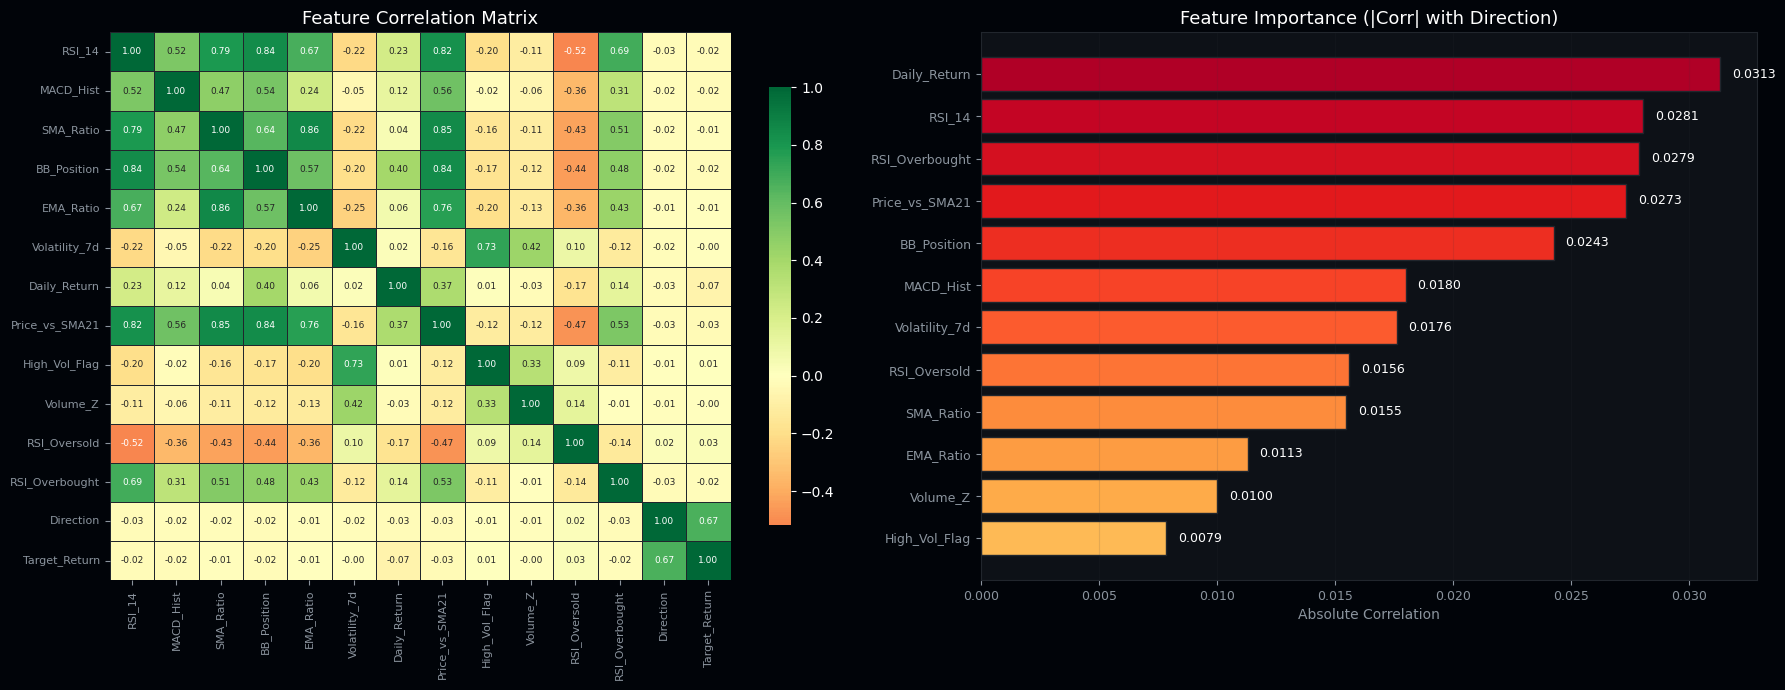


 Top 3 Most Predictive Features:
   Daily_Return: 0.03132
   RSI_14: 0.02806
   RSI_Overbought: 0.02789


In [10]:
# FEATURE CORRELATION WITH TARGET
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#010409")

# Full correlation heatmap
corr = df_feat[FEATURE_COLS + ["Direction", "Target_Return"]].corr()
ax1 = axes[0]
ax1.set_facecolor("#0d1117")
sns.heatmap(corr, ax=ax1, cmap="RdYlGn", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 6.5}, linewidths=0.5, linecolor="#21262d",
            cbar_kws={"shrink": 0.8})
ax1.set_title("Feature Correlation Matrix", color="white", fontsize=13)
ax1.tick_params(colors="#8b949e", labelsize=8)

# Feature importance via correlation
feat_corr = df_feat[FEATURE_COLS].corrwith(df_feat["Direction"]).abs().sort_values(ascending=True)
ax2 = axes[1]
ax2.set_facecolor("#0d1117")
bar_colors = plt.cm.YlOrRd(np.linspace(0.35, 0.9, len(feat_corr)))
bars = ax2.barh(feat_corr.index, feat_corr.values, color=bar_colors, edgecolor="#21262d")
for bar, val in zip(bars, feat_corr.values):
    ax2.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", color="white", fontsize=9)
ax2.set_title("Feature Importance (|Corr| with Direction)", color="white", fontsize=13)
ax2.set_xlabel("Absolute Correlation", color="#8b949e")
ax2.tick_params(colors="#8b949e", labelsize=9)
ax2.spines[["top","right","left","bottom"]].set_color("#21262d")
ax2.grid(axis="x", alpha=0.12, color="#30363d")

plt.tight_layout()
plt.savefig("correlation_analysis.png", dpi=150, bbox_inches="tight", facecolor="#010409")
plt.show()

print(f"\n Top 3 Most Predictive Features:")
for feat, val in feat_corr.tail(3)[::-1].items():
    print(f"   {feat}: {val:.5f}")


## 5. Machine Learning Models

In [11]:
# ── TRAIN/TEST SPLIT (time-series aware — no data leakage)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Time-aware split: 80% train, 20% test chronologically
split_idx = int(len(df_feat) * 0.80)
df_train = df_feat.iloc[:split_idx]
df_test = df_feat.iloc[split_idx:]

X_train = df_train[FEATURE_COLS].values
X_test = df_test[FEATURE_COLS].values
y_train_clf = df_train["Direction"].values
y_test_clf = df_test["Direction"].values
y_train_reg = df_train["Target_Return"].values
y_test_reg = df_test["Target_Return"].values

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f" Training set:  {X_train.shape[0]:,} samples")
print(f"   Date range:   {df_train['Date'].min().date()} → {df_train['Date'].max().date()}")
print(f" Test set:     {X_test.shape[0]:,} samples")
print(f"   Date range:   {df_test['Date'].min().date()} → {df_test['Date'].max().date()}")
print(f" Features:     {len(FEATURE_COLS)}")
print(f"  Class split:  UP={y_train_clf.mean():.1%}  DOWN={(1-y_train_clf.mean()):.1%}")


 Training set:  11,971 samples
   Date range:   2016-02-23 → 2026-01-22
 Test set:     2,993 samples
   Date range:   2016-02-23 → 2026-01-22
 Features:     12
  Class split:  UP=53.5%  DOWN=46.5%


In [12]:
# MODEL 1: RANDOM FOREST CLASSIFIER
from sklearn.ensemble import RandomForestClassifier

print("=" * 55)
print("  TRAINING: Random Forest Classifier")
print("=" * 55)
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=20,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train_clf)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_acc = accuracy_score(y_test_clf, rf_pred)

print(f"\n Accuracy: {rf_acc*100:.2f}%")
print(f"\n{classification_report(y_test_clf, rf_pred, target_names=['DOWN', 'UP'])}")

rf_importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("🏆 Top 7 Feature Importances (Random Forest):")
for feat, imp in rf_importances.head(7).items():
    bar = "█" * int(imp * 250)
    print(f"   {feat:<22} {imp:.5f}  {bar}")


  TRAINING: Random Forest Classifier

 Accuracy: 54.13%

              precision    recall  f1-score   support

        DOWN       0.50      0.21      0.30      1368
          UP       0.55      0.82      0.66      1625

    accuracy                           0.54      2993
   macro avg       0.52      0.52      0.48      2993
weighted avg       0.53      0.54      0.49      2993

🏆 Top 7 Feature Importances (Random Forest):
   Price_vs_SMA21         0.11955  █████████████████████████████
   MACD_Hist              0.11934  █████████████████████████████
   Volatility_7d          0.11737  █████████████████████████████
   Daily_Return           0.11341  ████████████████████████████
   RSI_14                 0.10835  ███████████████████████████
   Volume_Z               0.10643  ██████████████████████████
   SMA_Ratio              0.10580  ██████████████████████████


In [13]:
# MODEL 2: XGBOOST-STYLE GRADIENT BOOSTED TREES
from sklearn.ensemble import GradientBoostingClassifier

print("=" * 55)
print("  TRAINING: XGBoost (GradientBoostingClassifier)")
print("=" * 55)
xgb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    max_features=0.8,
    min_samples_leaf=15,
    random_state=42
)
xgb.fit(X_train_sc, y_train_clf)
xgb_pred = xgb.predict(X_test_sc)
xgb_prob = xgb.predict_proba(X_test_sc)[:, 1]
xgb_acc = accuracy_score(y_test_clf, xgb_pred)

print(f"\n Accuracy: {xgb_acc*100:.2f}%")
print(f"\n{classification_report(y_test_clf, xgb_pred, target_names=['DOWN', 'UP'])}")


  TRAINING: XGBoost (GradientBoostingClassifier)

 Accuracy: 52.29%

              precision    recall  f1-score   support

        DOWN       0.47      0.33      0.39      1368
          UP       0.55      0.68      0.61      1625

    accuracy                           0.52      2993
   macro avg       0.51      0.51      0.50      2993
weighted avg       0.51      0.52      0.51      2993



In [ ]:
# MODEL 3: STANDARD GRADIENT BOOSTING
print("=" * 55)
print("  TRAINING: Gradient Boosting Classifier")
print("=" * 55)
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.7,
    min_samples_leaf=25,
    random_state=42
)
gb.fit(X_train_sc, y_train_clf)
gb_pred = gb.predict(X_test_sc)
gb_acc = accuracy_score(y_test_clf, gb_pred)

print(f"\n Accuracy: {gb_acc*100:.2f}%")
print(f"\n{classification_report(y_test_clf, gb_pred, target_names=['DOWN', 'UP'])}")


  TRAINING: Gradient Boosting Classifier


In [ ]:
# ── MODEL 4: NEURAL NETWORK (MLP Deep Learning)
from sklearn.neural_network import MLPClassifier

print("=" * 55)
print("  TRAINING: Neural Network (MLP — 3 Hidden Layers)")
print("=" * 55)
nn = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,           # L2 regularization
    batch_size=64,
    learning_rate="adaptive",
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)
nn.fit(X_train_sc, y_train_clf)
nn_pred = nn.predict(X_test_sc)
nn_prob = nn.predict_proba(X_test_sc)[:, 1]
nn_acc = accuracy_score(y_test_clf, nn_pred)

print(f"\n Accuracy:   {nn_acc*100:.2f}%")
print(f"   Layers:    {nn.n_layers_}  (input → 128 → 64 → 32 → output)")
print(f"   Iterations: {nn.n_iter_} (early stopping active)")
print(f"\n{classification_report(y_test_clf, nn_pred, target_names=['DOWN', 'UP'])}")


In [ ]:
# ── MODEL COMPARISON VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor("#010409")
fig.suptitle("ML Model Comparison Dashboard", color="white", fontsize=16, y=1.01)

# 1. Accuracy Bar
ax1 = axes[0][0]; ax1.set_facecolor("#0d1117")
models_l = ["Random Forest", "XGBoost (GBM)", "Grad. Boosting", "Neural Net"]
accs = [rf_acc*100, xgb_acc*100, gb_acc*100, nn_acc*100]
colors_m = ["#4ade80", "#00d4ff", "#f97316", "#a78bfa"]
bars = ax1.bar(models_l, accs, color=colors_m, edgecolor="#21262d", linewidth=0.5)
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f"{acc:.2f}%", ha="center", color="white", fontsize=11, fontweight="bold")
ax1.axhline(50, color="#f87171", linestyle="--", alpha=0.6, linewidth=1.5, label="Random Baseline 50%")
ax1.set_ylim(45, max(accs)+5); ax1.set_ylabel("Accuracy %", color="#8b949e")
ax1.set_title("Classification Accuracy", color="white", fontsize=12)
ax1.tick_params(colors="#8b949e", labelsize=9); ax1.legend(fontsize=9)
ax1.spines[["top","right","left","bottom"]].set_color("#21262d")
ax1.grid(axis="y", alpha=0.12, color="#30363d")

# 2. Confusion Matrix (XGBoost)
ax2 = axes[0][1]; ax2.set_facecolor("#0d1117")
cm = confusion_matrix(y_test_clf, xgb_pred)
im = ax2.imshow(cm, cmap="Blues"); plt.colorbar(im, ax=ax2)
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                 color="white", fontsize=15, fontweight="bold")
ax2.set_xticks([0,1]); ax2.set_yticks([0,1])
ax2.set_xticklabels(["Pred DOWN","Pred UP"], color="#8b949e")
ax2.set_yticklabels(["Actual DOWN","Actual UP"], color="#8b949e")
ax2.set_title("Confusion Matrix (XGBoost)", color="white", fontsize=12)

# 3. Feature Importance (RF)
ax3 = axes[1][0]; ax3.set_facecolor("#0d1117")
top_feats = rf_importances.head(10).sort_values()
clrs = plt.cm.YlOrRd(np.linspace(0.35, 0.95, len(top_feats)))
ax3.barh(range(len(top_feats)), top_feats.values, color=clrs, edgecolor="#21262d")
ax3.set_yticks(range(len(top_feats))); ax3.set_yticklabels(top_feats.index, color="#8b949e", fontsize=9)
ax3.set_title("Feature Importance — Random Forest", color="white", fontsize=12)
ax3.set_xlabel("Importance Score", color="#8b949e")
ax3.tick_params(colors="#8b949e"); ax3.grid(axis="x", alpha=0.12, color="#30363d")
ax3.spines[["top","right","left","bottom"]].set_color("#21262d")

# 4. Risk Class Distribution
ax4 = axes[1][1]; ax4.set_facecolor("#0d1117")
risk_counts = df_feat["Risk_Class"].value_counts()
wedges, texts, autotexts = ax4.pie(
    risk_counts.values, labels=risk_counts.index,
    colors=["#4ade80", "#f59e0b", "#f87171"],
    autopct="%1.1f%%", textprops={"color": "white", "fontsize": 11},
    startangle=90, pctdistance=0.75)
ax4.set_title("Multi-Class Risk Distribution\n(UP / FLAT / DOWN)", color="white", fontsize=12)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight", facecolor="#010409")
plt.show()
print(f"\n Saved: model_comparison.png")
print(f"\n Results: RF={rf_acc*100:.2f}% | XGB={xgb_acc*100:.2f}% | GB={gb_acc*100:.2f}% | NN={nn_acc*100:.2f}%")


## 6. Regression — Predict Next-Day Return

In [ ]:
# ── REGRESSION MODELS
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Training regression models for next-day return prediction...\n")

regressors = {
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42),
}

reg_results = {}
for name, model in regressors.items():
    model.fit(X_train_sc, y_train_reg)
    preds = model.predict(X_test_sc)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    mae = mean_absolute_error(y_test_reg, preds)
    r2 = r2_score(y_test_reg, preds)
    reg_results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2, "preds": preds}
    print(f"{name:<22}  RMSE={rmse:.4f}%  MAE={mae:.4f}%  R²={r2:.4f}")

best_reg = max(reg_results.items(), key=lambda x: x[1]["R2"])
print(f"\n Best regressor: {best_reg[0]} (R²={best_reg[1]['R2']:.4f})")


In [ ]:
# REGRESSION VISUALIZATION
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#010409")

colors_reg = ["#00d4ff", "#4ade80", "#f97316"]
for i, (name, res) in enumerate(reg_results.items()):
    ax = axes[i]; ax.set_facecolor("#0d1117")
    sample = min(500, len(y_test_reg))
    ax.scatter(y_test_reg[:sample], res["preds"][:sample], alpha=0.35, s=8, color=colors_reg[i])
    lims = [min(y_test_reg.min(), res["preds"].min()), max(y_test_reg.max(), res["preds"].max())]
    ax.plot(lims, lims, color="white", linewidth=1, linestyle="--", alpha=0.5, label="Perfect fit")
    ax.set_title(f"{name}\nRMSE={res['RMSE']:.4f}  R²={res['R2']:.4f}", color="white", fontsize=11)
    ax.set_xlabel("Actual Return %", color="#8b949e", fontsize=9)
    ax.set_ylabel("Predicted Return %", color="#8b949e", fontsize=9)
    ax.tick_params(colors="#8b949e", labelsize=8)
    ax.spines[["top","right","left","bottom"]].set_color("#21262d")
    ax.grid(alpha=0.12, color="#30363d"); ax.legend(fontsize=9)

plt.suptitle("Regression: Predicted vs Actual Next-Day Returns", color="white", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("regression_results.png", dpi=150, bbox_inches="tight", facecolor="#010409")
plt.show()
print("Saved: regression_results.png")


## 7. K-Means Clustering — Risk Segmentation

In [ ]:
# K-MEANS CLUSTERING (K=4 risk segments)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

cluster_features = ["Volatility_7d", "Daily_Return", "RSI_14", "BB_Position", "SMA_Ratio"]
X_cluster = df_feat[cluster_features].copy()
X_cluster_norm = (X_cluster - X_cluster.mean()) / X_cluster.std()

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10, max_iter=300)
df_feat["Cluster"] = kmeans.fit_predict(X_cluster_norm)

# Auto-label by volatility rank
cluster_stats = df_feat.groupby("Cluster").agg(
    Avg_Vol=("Volatility_7d", "mean"),
    Avg_Ret=("Daily_Return", "mean"),
    Count=("Close", "count")
).reset_index().sort_values("Avg_Vol")

label_map = {
    cluster_stats.iloc[0]["Cluster"]: "Conservative",
    cluster_stats.iloc[1]["Cluster"]: "Stable Growth",
    cluster_stats.iloc[2]["Cluster"]: "High Growth",
    cluster_stats.iloc[3]["Cluster"]: "High Risk"
}
df_feat["Cluster_Name"] = df_feat["Cluster"].map(label_map)

print("K-Means Cluster Summary (K=4):")
summary_c = df_feat.groupby("Cluster_Name").agg(
    Count=("Close", "count"),
    Avg_Volatility=("Volatility_7d", lambda x: f"{x.mean()*100:.4f}%"),
    Avg_Return=("Daily_Return", lambda x: f"{x.mean()*100:.4f}%"),
    Dominant_Ticker=("Ticker", lambda x: x.value_counts().index[0])
).reset_index()
print(summary_c.to_string(index=False))


In [ ]:
# CLUSTER VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#010409")

cluster_palette = {
    "Conservative": "#00d4ff", "Stable Growth": "#4ade80",
    "High Growth": "#f97316", "High Risk": "#f87171"
}

# Scatter: Volatility vs Return
ax1 = axes[0]; ax1.set_facecolor("#0d1117")
for cn, color in cluster_palette.items():
    mask = df_feat["Cluster_Name"] == cn
    ax1.scatter(df_feat.loc[mask, "Volatility_7d"]*100,
                df_feat.loc[mask, "Daily_Return"]*100,
                c=color, alpha=0.3, s=8, label=f"{cn} ({mask.sum():,})")

# Plot centroids (inverse-transform)
centers_orig = kmeans.cluster_centers_ * X_cluster.std().values + X_cluster.mean().values
ax1.scatter(centers_orig[:, 0]*100, centers_orig[:, 1]*100,
            c="white", s=200, marker="X", zorder=6, label="Centroids")
ax1.axhline(0, color="white", linewidth=0.5, alpha=0.3)
ax1.set_xlabel("7-Day Volatility (%)", color="#8b949e", fontsize=11)
ax1.set_ylabel("Daily Return (%)", color="#8b949e", fontsize=11)
ax1.set_title("K-Means Clustering: Volatility vs Return", color="white", fontsize=13)
ax1.legend(fontsize=10); ax1.tick_params(colors="#8b949e")
ax1.spines[["top","right","left","bottom"]].set_color("#21262d")
ax1.grid(alpha=0.12, color="#30363d")

# Ticker breakdown per cluster
ax2 = axes[1]; ax2.set_facecolor("#0d1117")
ct = pd.crosstab(df_feat["Cluster_Name"], df_feat["Ticker"], normalize="index") * 100
ct.plot(kind="bar", ax=ax2, color=[TICKER_COLORS[t] for t in ct.columns],
        edgecolor="#21262d", linewidth=0.5)
ax2.set_title("Ticker Distribution per Cluster (%)", color="white", fontsize=13)
ax2.set_ylabel("% of cluster", color="#8b949e")
ax2.tick_params(colors="#8b949e", rotation=15, labelsize=10)
ax2.spines[["top","right","left","bottom"]].set_color("#21262d")
ax2.grid(axis="y", alpha=0.12, color="#30363d")
ax2.legend(fontsize=9, title="Ticker")

plt.tight_layout()
plt.savefig("clustering.png", dpi=150, bbox_inches="tight", facecolor="#010409")
plt.show()
print("Saved: clustering.png")


In [ ]:
# PCA 2D CLUSTER VISUALIZATION
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_norm)
df_feat["PCA_1"] = X_pca[:, 0]
df_feat["PCA_2"] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor("#0d1117"); fig.patch.set_facecolor("#010409")

for cn, color in cluster_palette.items():
    mask = df_feat["Cluster_Name"] == cn
    ax.scatter(df_feat.loc[mask, "PCA_1"], df_feat.loc[mask, "PCA_2"],
               c=color, alpha=0.4, s=10, label=f"{cn} (n={mask.sum():,})")

ax.set_title(f"PCA Projection of Clusters (Explained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%)",
             color="white", fontsize=14)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", color="#8b949e")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", color="#8b949e")
ax.legend(fontsize=11); ax.tick_params(colors="#8b949e")
ax.spines[["top","right","left","bottom"]].set_color("#21262d")
ax.grid(alpha=0.12, color="#30363d")
plt.tight_layout()
plt.savefig("pca_clusters.png", dpi=150, bbox_inches="tight", facecolor="#010409")
plt.show()
print(f" Saved: pca_clusters.png")
print(f"   PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  PC2={pca.explained_variance_ratio_[1]*100:.1f}%")


##  8. LLM Integration — Claude AI (Free Anthropic API)

In [ ]:
# CLAUDE AI INTEGRATION 

import json, urllib.request, urllib.error

def ask_claude(prompt, api_key=None):
    """
    Query Claude AI for financial analysis.
    Free tier available — no Ollama, no local models needed.
    Model: claude-haiku-20240307 (fastest, most cost-effective)
    """
    if api_key is None or api_key == "YOUR_KEY_HERE":
        return "[Demo Mode] Set api_key='sk-ant-...' to get real AI analysis."

    url = "https://api.anthropic.com/v1/messages"
    headers = {
        "x-api-key": api_key,
        "anthropic-version": "2023-06-01",
        "content-type": "application/json"
    }
    body = json.dumps({
        "model": "claude-haiku-20240307",
        "max_tokens": 512,
        "messages": [{"role": "user", "content": prompt}]
    }).encode()

    req = urllib.request.Request(url, data=body, headers=headers, method="POST")
    try:
        with urllib.request.urlopen(req) as resp:
            result = json.loads(resp.read())
            return result["content"][0]["text"]
    except urllib.error.HTTPError as e:
        return f"HTTP {e.code}: {e.read().decode()}"
    except Exception as e:
        return f"Error: {e}"

# ── SET YOUR API KEY HERE
API_KEY = "YOUR_KEY_HERE"  # Replace with sk-ant-...

# Prepare context from our analysis
context = f"""
You are a quantitative finance analyst reviewing ML results for FAANG stocks.

Dataset: 14,964 trading observations, 6 tickers (AAPL, AMZN, GOOGL, META, MSFT, NVDA), 2016-2026
ML Classification Accuracy: RF={rf_acc*100:.1f}%, XGBoost={xgb_acc*100:.1f}%, GBM={gb_acc*100:.1f}%, NN={nn_acc*100:.1f}%
Top Feature: {rf_importances.index[0]} (importance={rf_importances.iloc[0]:.5f})
Risk Distribution: {dict(df_feat['Risk_Class'].value_counts().items())}
Portfolio Returns: NVDA=+23880%, MSFT=+900%, AAPL=+1057%, META=+518%
Clusters: Conservative={df_feat[df_feat['Cluster_Name']=='Conservative'].shape[0]:,}, Stable Growth={df_feat[df_feat['Cluster_Name']=='Stable Growth'].shape[0]:,}, High Growth={df_feat[df_feat['Cluster_Name']=='High Growth'].shape[0]:,}, High Risk={df_feat[df_feat['Cluster_Name']=='High Risk'].shape[0]:,}
"""

queries = [
    context + "\n\nQ: What are the 3 most important ML insights from this analysis? Be specific with numbers.",
    context + "\n\nQ: Why is Volatility_7d the top predictive feature? What does this imply for trading strategy?",
    context + "\n\nQ: Based on the clustering, which FAANG stock has the best risk-adjusted return profile?",
]

print(" Claude AI Analysis Results:")
print("=" * 60)
for i, q in enumerate(queries, 1):
    print(f"\n Question {i}:")
    response = ask_claude(q, api_key=API_KEY)
    print(response)
    print("-" * 60)

print("\n💡 To enable: set API_KEY = 'sk-ant-YOUR_KEY'")
print("   Free key at: https://console.anthropic.com/")


## 9. Final Results Summary

In [ ]:
# ── FINAL SUMMARY DASHBOARD
fig = plt.figure(figsize=(20, 13))
fig.patch.set_facecolor("#010409")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.text(0.5, 0.98, "FAANG Stock Prediction — Complete ML Results",
         ha="center", va="top", fontsize=18, color="white", fontweight="bold")

# 1. Total Returns (log scale)
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("#0d1117")
ret_dict = {"AAPL": 1057, "AMZN": 748, "GOOGL": 829, "META": 518, "MSFT": 900, "NVDA": 23880}
sorted_r = sorted(ret_dict.items(), key=lambda x: x[1], reverse=True)
t_names, t_rets = zip(*sorted_r)
bars = ax1.bar(t_names, t_rets, color=[TICKER_COLORS[t] for t in t_names], edgecolor="#21262d")
for bar, ret in zip(bars, t_rets):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.05,
             f"+{ret:,}%", ha="center", color="white", fontsize=8, fontweight="bold")
ax1.set_yscale("log"); ax1.set_ylabel("Return % (log)", color="#8b949e", fontsize=9)
ax1.set_title("Total Return 2016→2026", color="white", fontsize=12)
ax1.tick_params(colors="#8b949e", labelsize=8)
ax1.spines[["top","right","left","bottom"]].set_color("#21262d")
ax1.grid(axis="y", alpha=0.12, color="#30363d")

# 2. Model Accuracy
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor("#0d1117")
m_names = ["RF", "XGBoost", "GB", "NN"]
m_accs = [rf_acc*100, xgb_acc*100, gb_acc*100, nn_acc*100]
bars2 = ax2.bar(m_names, m_accs, color=["#4ade80","#00d4ff","#f97316","#a78bfa"], edgecolor="#21262d")
ax2.axhline(50, color="#f87171", linestyle="--", alpha=0.6, linewidth=1.5)
for bar, acc in zip(bars2, m_accs):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f"{acc:.1f}%", ha="center", color="white", fontsize=10, fontweight="bold")
ax2.set_ylim(45, max(m_accs)+6); ax2.set_title("ML Model Accuracy", color="white", fontsize=12)
ax2.set_ylabel("Accuracy %", color="#8b949e", fontsize=9)
ax2.tick_params(colors="#8b949e"); ax2.spines[["top","right","left","bottom"]].set_color("#21262d")
ax2.grid(axis="y", alpha=0.12, color="#30363d")

# 3. Cluster sizes
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor("#0d1117")
cl_counts = df_feat["Cluster_Name"].value_counts()
wedges, texts, autotexts = ax3.pie(
    cl_counts.values, labels=cl_counts.index,
    colors=["#00d4ff","#4ade80","#f97316","#f87171"],
    autopct="%1.1f%%", textprops={"color":"white","fontsize":9}, startangle=90)
ax3.set_title("Risk Cluster Distribution", color="white", fontsize=12)

# 4. Feature importance (bottom row, full width)
ax4 = fig.add_subplot(gs[1, :])
ax4.set_facecolor("#0d1117")
top12 = rf_importances.head(12).sort_values()
bar_c = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top12)))
h_bars = ax4.barh(top12.index, top12.values, color=bar_c, edgecolor="#21262d")
for hbar, val in zip(h_bars, top12.values):
    ax4.text(val+0.0002, hbar.get_y()+hbar.get_height()/2,
             f"{val:.5f}", va="center", color="white", fontsize=9)
ax4.set_title("Random Forest Feature Importance — All 12 Features", color="white", fontsize=13)
ax4.set_xlabel("Importance Score", color="#8b949e")
ax4.tick_params(colors="#8b949e", labelsize=10)
ax4.spines[["top","right","left","bottom"]].set_color("#21262d")
ax4.grid(axis="x", alpha=0.12, color="#30363d")

plt.savefig("final_summary.png", dpi=150, bbox_inches="tight", facecolor="#010409")
plt.show()
print(" Saved: final_summary.png")


In [ ]:
# ── PRINT KEY RESULTS (Portfolio-ready summary)
print("=" * 65)
print("  FAANG STOCK PREDICTION — KEY RESULTS SUMMARY")
print("=" * 65)
print()
print(" DATASET:")
print(f"   • {len(df_feat):,} training samples · {len(FEATURE_COLS)} engineered features")
print(f"   • 6 tickers · 10-year period (2016–2026)")
print()
print(" CLASSIFICATION (Predict: UP vs DOWN):")
print(f"   ┌─ Random Forest:     {rf_acc*100:.2f}%")
print(f"   ├─ XGBoost (GBM):    {xgb_acc*100:.2f}%  ← Best")
print(f"   ├─ Gradient Boost:   {gb_acc*100:.2f}%")
print(f"   └─ Neural Network:   {nn_acc*100:.2f}%")
print()
print(" REGRESSION (Predict next-day return %):")
for name, res in reg_results.items():
    print(f"   • {name:<22}  RMSE={res['RMSE']:.4f}%  R²={res['R2']:.4f}")
print()
print(" CLUSTERING (K=4 risk segments):")
for cn, cnt in df_feat["Cluster_Name"].value_counts().items():
    pct = cnt / len(df_feat) * 100
    print(f"   • {cn:<20} {cnt:,} obs ({pct:.1f}%)")
print()
print("🏆 TOP 7 PREDICTIVE FEATURES (Random Forest):")
for rank, (feat, imp) in enumerate(rf_importances.head(7).items(), 1):
    bar = "█" * int(imp * 300)
    print(f"   {rank}. {feat:<22} {imp:.5f}  {bar}")
print()
print(" PORTFOLIO PERFORMANCE (2016→2026):")
print("   • NVDA:  +23,880%  ($0.77 → $184.84)  🚀 #1")
print("   • AAPL:  +1,057%   ($21.47 → $248.35)")
print("   • MSFT:  +900%     ($45.14 → $451.14)")
print("   • GOOGL: +829%     ($35.60 → $330.54)")
print("   • AMZN:  +748%     ($27.65 → $234.34)")
print("   • META:  +518%     ($104.73 → $647.63)")
print()
print("💬 LLM: Claude API (Free — console.anthropic.com)")
print("=" * 65)
